# DXA позвоночника: сравнение методов без обучения

Ноутбук выделен из `DXA_prototype_v5_5.ipynb`. Сохранены чтение DICOM (`pydicom` + LUT, инверсия MONOCHROME1), мягкое отсечение фона и выбор снимков `SPINE` из `Размеченные/labels.csv`. Обучение классификаторов, анализ бедра и жёсткая проверка количества файлов убраны.

**Что изображается:** 1) профиль яркости и кандидаты промежутков, 2) края Canny и линии Hough, 3) пути минимальной стоимости через межпозвонковые промежутки, 4) локальные оси между этими промежутками, 5) при наличии весов MedSAM — маски и полученная по ним геометрия, 6) при наличии исходного кода, весов и CUDA — экспериментальный запуск RouterNet, четыре ориентира и геометрия. Все координаты в пикселях исходного изображения. Вывод алгоритма — исследовательская гипотеза, для анатомического уровня и качества нужен экспертный контроль.

Если набор снимков недоступен, базовые методы запускаются на **явно обозначенном искусственном изображении**. Инференс RouterNet на нём не запускается; для реального снимка код может скачать официальный репозиторий с весами, но дополнительно требуется настроенное CUDA-окружение.

## 0. Зависимости и настройки

Для базовых методов: `%pip install numpy pandas matplotlib scipy opencv-python pydicom pillow`. Для компрессированных DICOM с JPEG может понадобиться `%pip install pylibjpeg pylibjpeg-libjpeg`. МедSAM устанавливайте в отдельном окружении по [официальному репозиторию](https://github.com/bowang-lab/MedSAM), с его весами `medsam_vit_b.pth`; одноимённые обычные веса SAM не подходят. RouterNet запускается в своём окружении: [репозиторий и инструкция](https://github.com/YingJGuo/RouterNet).

In [1]:
from pathlib import Path, PurePosixPath
import csv, json, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pydicom
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import find_peaks
try:
    from pydicom.pixels import apply_modality_lut, apply_voi_lut
except ImportError:
    from pydicom.pixel_data_handlers.util import apply_modality_lut, apply_voi_lut

# Поменяйте путь на папку со структурой из исходного ноутбука.
DATASET_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")
STUDIES_ROOT = DATASET_ROOT / "Исследования"
LABELS_CSV = DATASET_ROOT / "Размеченные" / "labels.csv"
OUTPUT_DIR = DATASET_ROOT / "spine_method_comparison"
SAMPLE_INDEX = 0  # индекс среди строк SPINE
ROI_FRACTIONS = (0.22, 0.78, 0.035, 0.95)  # x0,x1,y0,y1; при необходимости измените
MANUAL_ROI = None  # например (120, 20, 500, 900), координаты полного изображения
INVERT_FOR_GAPS = False  # менять только после просмотра исходной яркости
EXPECTED_GAPS = 5  # L1/L2 ... L5/S1; может не соответствовать реальному полю зрения
RUN_MEDSAM = False
RUN_SAM2 = False
MEDSAM_CHECKPOINT = DATASET_ROOT / "medsam_vit_b.pth"
SAM2_CHECKPOINT = DATASET_ROOT / "sam2_hiera_tiny.pt"
SAM2_CONFIG = "configs/sam2/sam2_hiera_t.yaml"  # согласуйте с версией своего sam2
# Прямоугольники XYXY задаются в пикселях исходного изображения, по одному на тело.
VERTEBRA_BOXES = {}  # пример: {"L1": (x0,y0,x1,y1), "L2": (...)}
ROUTERNET_CSV = OUTPUT_DIR / "routernet_landmarks.csv"
# Клонируйте официальный репозиторий в эту папку (см. секцию RouterNet).
ROUTERNET_REPO = DATASET_ROOT / "RouterNet"
ROUTERNET_CHECKPOINT = ROUTERNET_REPO / "model" / "Jul25-1445_root_8" / "best_corner"
RUN_ROUTERNET = True
AUTO_CLONE_ROUTERNET = True  # при отсутствии папки скачать официальный репозиторий с весами через git
# Прямоугольник инициализации в координатах входа сети 384 x 704 (x0,y0,x1,y1).
# None вычисляет его по ROI. На кадре только с поясницей 17 уровней не определить автоматически.
ROUTERNET_BBOX_704 = None
# Начальное отсутствие датасета вызывает демонстрацию только на синтетике.

## 1. Загрузка DICOM и выбор снимка

Нормализация и фильтрация ниже перенесены из вашего исходного ноутбука. Таблица может измениться по размеру: число 166 здесь не зашито. Идентификаторы пациентов не выводятся.

SPINE: 166, пример: CR000000.dcm, shape=(289, 300), spacing=None


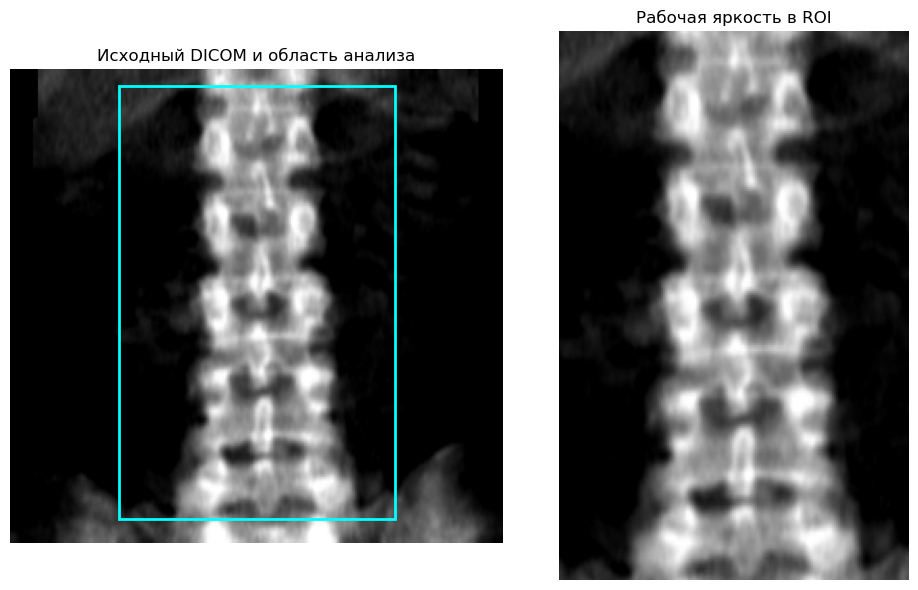

In [2]:
def normalize_relpath(value):
    return str(value or "").strip().replace("\\", "/").lstrip("./")

def rel_to_path(value):
    return Path(*PurePosixPath(normalize_relpath(value)).parts)

def read_dicom_image(path):
    ds = pydicom.dcmread(path, force=True)
    arr = np.squeeze(np.asarray(ds.pixel_array))
    if arr.ndim != 2:
        raise ValueError(f"Ожидался один 2D DXA-кадр, получено {arr.shape}: {path}")
    arr = np.asarray(apply_modality_lut(arr, ds), dtype=np.float32)
    try:
        arr = np.asarray(apply_voi_lut(arr, ds), dtype=np.float32)
    except Exception:
        pass
    finite = np.isfinite(arr)
    if not finite.any():
        raise ValueError(f"Нет конечных значений PixelData: {path}")
    lo, hi = np.nanpercentile(arr[finite], [0.5, 99.5])
    if hi <= lo:
        lo, hi = np.nanmin(arr[finite]), np.nanmax(arr[finite])
    img = np.clip((arr - lo) / max(hi - lo, 1e-6), 0, 1)
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        img = 1 - img
    return ds, img.astype(np.float32)

def threshold_background(img, q=0.01):
    positive = img[img > 0]
    if not len(positive):
        return img.copy(), 0.0
    threshold = float(np.quantile(positive, q))
    out = img.copy()
    out[out < threshold] = 0
    return out, threshold

def preprocess_dicom(path):
    ds, img = read_dicom_image(path)
    filtered, threshold = threshold_background(img)
    return ds, img, filtered, threshold

def pixel_spacing_mm(ds):
    for name in ("PixelSpacing", "ImagerPixelSpacing", "NominalScannedPixelSpacing"):
        val = getattr(ds, name, None)
        if val is not None and len(val) >= 2:
            try:
                row, col = float(val[0]), float(val[1])
                if row > 0 and col > 0:
                    return row, col
            except (TypeError, ValueError):
                pass
    return None

def load_spine_paths():
    if not LABELS_CSV.is_file() or not STUDIES_ROOT.is_dir():
        return []
    labels = pd.read_csv(LABELS_CSV, dtype=str).fillna("")
    needed = {"relative_path", "label"}
    if not needed.issubset(labels.columns):
        raise ValueError(f"В labels.csv отсутствуют поля {sorted(needed - set(labels.columns))}")
    rows = labels.loc[labels.label.str.strip().str.upper().eq("SPINE")].copy()
    paths = [STUDIES_ROOT / rel_to_path(x) for x in rows.relative_path]
    missing = [p for p in paths if not p.is_file()]
    if missing:
        raise FileNotFoundError(f"Нет {len(missing)} файлов SPINE; первый: {missing[0]}")
    return paths

def synthetic_spine(seed=7, height=720, width=460):
    """Только проверка кода. Не трактовать как модель реальной анатомии."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[:height, :width]
    img = 0.045 + 0.025*rng.standard_normal((height, width))
    img += 0.09*np.exp(-((xx-width*.5)/(width*.4))**2)
    for i in range(6):
        cy = 70 + 100*i
        cx = width*.50 + 12*np.sin(i*.55)
        top = cy - 32 + (xx-cx)*(.025*np.sin(i))
        bottom = cy + 30 + (xx-cx)*(.025*np.sin(i))
        edge = np.clip((xx-(cx-72))/4, 0, 1)*np.clip(((cx+72)-xx)/4, 0, 1)
        img += .52*edge*np.clip((yy-top)/4,0,1)*np.clip((bottom-yy)/4,0,1)
    img = gaussian_filter(img, 1.5)
    return np.clip(img,0,1).astype(np.float32)

spine_paths = load_spine_paths()
if spine_paths:
    if not 0 <= SAMPLE_INDEX < len(spine_paths):
        raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX}, доступно {len(spine_paths)} снимков")
    sample_path = spine_paths[SAMPLE_INDEX]
    ds, image, filtered, bg_thr = preprocess_dicom(sample_path)
    spacing = pixel_spacing_mm(ds)
    image_id = sample_path.stem
    is_synthetic = False
    print(f"SPINE: {len(spine_paths)}, пример: {sample_path.name}, shape={image.shape}, spacing={spacing}")
else:
    sample_path, spacing, ds = None, None, None
    image = synthetic_spine()
    filtered, bg_thr = threshold_background(image)
    image_id = "SYNTHETIC_EXAMPLE"
    is_synthetic = True
    print("ДАТАСЕТ НЕ НАЙДЕН: визуализации ниже построены на искусственном примере, не на DXA!")

if INVERT_FOR_GAPS:
    analysis_img = 1.0 - image
else:
    analysis_img = filtered

def roi_box(img):
    h, w = img.shape
    if MANUAL_ROI is None:
        a,b,c,d = ROI_FRACTIONS
        box = (int(w*a), int(h*c), int(w*b), int(h*d))
    else:
        box = tuple(int(v) for v in MANUAL_ROI)
    x0,y0,x1,y1 = box
    if not (0 <= x0 < x1 <= w and 0 <= y0 < y1 <= h):
        raise ValueError(f"Неверный ROI {box}, размер изображения {img.shape}")
    return box

x0,y0,x1,y1 = roi_box(image)
roi = analysis_img[y0:y1, x0:x1]
fig,ax = plt.subplots(1,2,figsize=(10,6))
ax[0].imshow(image,cmap='gray',vmin=0,vmax=1)
ax[0].add_patch(Rectangle((x0,y0),x1-x0,y1-y0,fill=False,color='cyan',lw=2))
ax[0].set_title('Исходный DICOM и область анализа')
ax[1].imshow(roi,cmap='gray',vmin=0,vmax=1)
ax[1].set_title('Рабочая яркость в ROI')
for a in ax:a.axis('off')
plt.tight_layout(); plt.show()

## 2. Общие измерения: центральная линия и профиль яркости

Средневзвешенный центр ярких пикселей в центральной части ROI служит начальной осью. Это **не** ось каждого позвонка; она нужна для ограничения полос анализа. Если на реальном DXA центр смещается к подвздошной кости или артефакту, поправьте `MANUAL_ROI`. Пики ищутся на отрицательном сглаженном профиле, без принудительной выдачи ровно пяти промежутков.

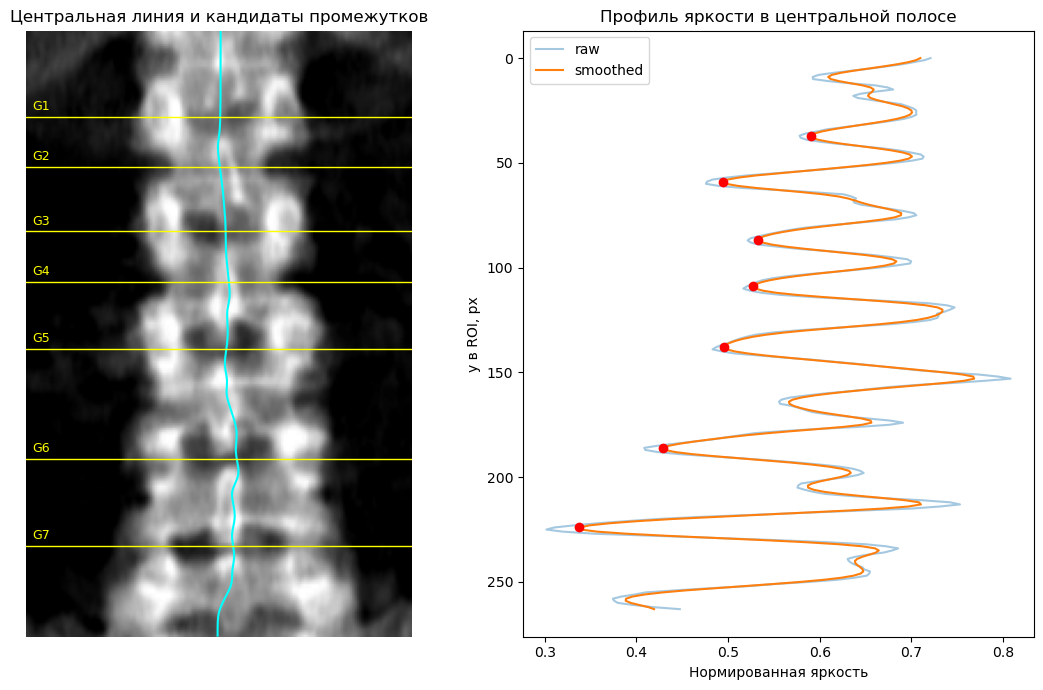

Кандидаты y полного кадра: [47, 69, 97, 119, 148, 196, 234] ; число: 7


In [3]:
def centerline_and_profile(a):
    h,w = a.shape
    xlo,xhi = int(.20*w),int(.80*w)
    region = gaussian_filter(a[:,xlo:xhi].astype(np.float32),1.2)
    bg = np.quantile(a,.15,axis=1,keepdims=True)
    weights = np.maximum(region-bg,0)**1.4
    mass = weights.sum(axis=1)
    good = mass > max(float(np.quantile(mass,.60)),float(mass.max())*.18,1e-6)
    xs = np.arange(xlo,xhi)
    center = np.full(h,w/2.,dtype=float)
    if good.sum() >= 3:
        measured = (weights[good]@xs)/np.maximum(mass[good],1e-9)
        center = np.interp(np.arange(h),np.flatnonzero(good),measured)
    center = np.clip(gaussian_filter1d(center,max(3,h*.012)),w*.22,w*.78)
    half = max(8,int(.16*w))
    profile = np.empty(h,float)
    for y in range(h):
        cx = int(center[y])
        stripe = a[y,max(0,cx-half):min(w,cx+half+1)]
        profile[y] = np.mean(stripe) if len(stripe) else np.nan
    smooth = gaussian_filter1d(profile,max(2,h*.007))
    return center,profile,smooth

def detect_gaps(profile, n_hint=5):
    h=len(profile)
    edge=max(8,int(.04*h))
    min_distance=max(12,int(h/(n_hint+3)*.65))
    prominence=max(.018,float(np.std(profile))*.27)
    peaks,props=find_peaks(-profile,distance=min_distance,prominence=prominence)
    valid=(peaks>=edge)&(peaks<h-edge)
    peaks=peaks[valid]
    prominences=props['prominences'][valid]
    if n_hint is not None and len(peaks)>n_hint+2:
        keep=np.sort(np.argsort(prominences)[-(n_hint+2):])
        peaks,prominences=peaks[keep],prominences[keep]
    return peaks.astype(int),prominences

center,profile,profile_smooth=centerline_and_profile(roi)
gaps,strengths=detect_gaps(profile_smooth,EXPECTED_GAPS)
fig,ax=plt.subplots(1,2,figsize=(11,7))
ax[0].imshow(roi,cmap='gray');ax[0].plot(center,np.arange(len(center)),color='cyan',lw=1.5)
for j,g in enumerate(gaps):
    ax[0].axhline(g,color='yellow',lw=1.0)
    ax[0].text(2,int(g)-3,f'G{j+1}',color='yellow',fontsize=9)
ax[0].set_title('Центральная линия и кандидаты промежутков');ax[0].axis('off')
ax[1].plot(profile,np.arange(len(profile)),alpha=.4,label='raw')
ax[1].plot(profile_smooth,np.arange(len(profile)),label='smoothed')
ax[1].scatter(profile_smooth[gaps],gaps,c='red',zorder=3)
ax[1].invert_yaxis();ax[1].set_title('Профиль яркости в центральной полосе')
ax[1].set_xlabel('Нормированная яркость');ax[1].set_ylabel('y в ROI, px');ax[1].legend()
plt.tight_layout();plt.show()
print('Кандидаты y полного кадра:', (gaps+y0).tolist(), '; число:', len(gaps))

## 3. Canny + локальный Hough

Для каждой найденной строки ищем почти горизонтальные сегменты в её окрестности. Сегменты отображаются **как найденные**, без искусственного продления: поперечные тени и подвздошные кости могут давать ложные линии.

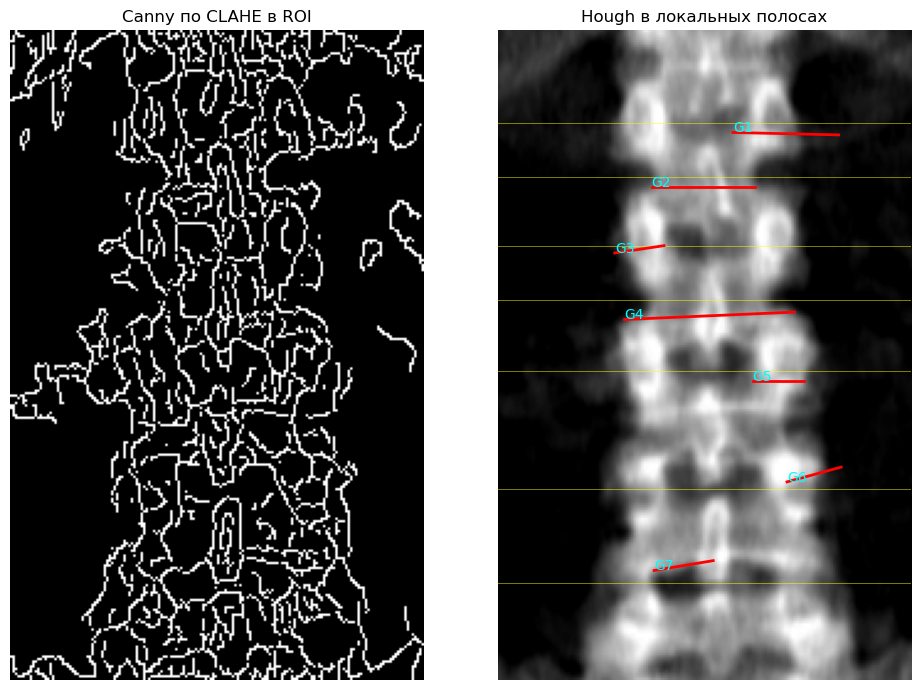

Найдено локальных линий: 7 из 7


In [4]:
def hough_gap_lines(a,seeds,center):
    h,w=a.shape
    local=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8)).apply(np.uint8(np.clip(a,0,1)*255))
    canny=cv2.Canny(local,45,120)
    results=[]
    for y in seeds:
        cy=int(round(center[y]));half_w=max(12,int(.34*w));half_h=max(8,int(.035*h))
        xa,xb=max(0,cy-half_w),min(w,cy+half_w)
        ya,yb=max(0,int(y)-half_h),min(h,int(y)+half_h+1)
        patch=canny[ya:yb,xa:xb]
        raw=cv2.HoughLinesP(patch,1,np.pi/180,threshold=max(12,int(.04*w)),
                            minLineLength=max(12,int(.12*w)),maxLineGap=max(4,int(.03*w)))
        candidates=[]
        if raw is not None:
            for x1_,y1_,x2_,y2_ in np.asarray(raw).reshape(-1,4):
                p=np.array([x1_+xa,y1_+ya,x2_+xa,y2_+ya],dtype=float)
                dx,dy=p[2]-p[0],p[3]-p[1]
                length=np.hypot(dx,dy)
                angle=np.degrees(np.arctan2(dy,dx))
                if abs(angle)>25:continue
                center_dist=abs((p[1]+p[3])/2-y)
                score=length/(1+center_dist/max(2,half_h/2))
                candidates.append((score,p))
        best=max(candidates,key=lambda z:z[0])[1] if candidates else None
        results.append({'seed_y':int(y),'line':best,'candidates':len(candidates)})
    return local,canny,results

clahe,canny,hough=hough_gap_lines(roi,gaps,center)
fig,ax=plt.subplots(1,2,figsize=(10,7))
ax[0].imshow(canny,cmap='gray');ax[0].set_title('Canny по CLAHE в ROI')
ax[1].imshow(roi,cmap='gray');ax[1].set_title('Hough в локальных полосах')
for i,r in enumerate(hough):
    ax[1].axhline(r['seed_y'],color='yellow',alpha=.5,lw=.7)
    if r['line'] is not None:
        p=r['line'];ax[1].plot([p[0],p[2]],[p[1],p[3]],color='red',lw=2)
        ax[1].text(p[0],p[1],f'G{i+1}',color='cyan')
for a in ax:a.axis('off')
plt.tight_layout();plt.show()
print('Найдено локальных линий:',sum(r['line'] is not None for r in hough),'из',len(hough))

## 4. Поиск тёмного пути слева направо

Динамическое программирование минимизирует яркость и изменение высоты пути в узкой полосе около каждого кандидата. Допустимы переходы на −2…+2 пикселя в соседнем столбце. Это линия внутри предполагаемого *промежутка*, а не выделенная замыкательная пластинка. Вывод «нет пути» означает отсутствие начального кандидата.

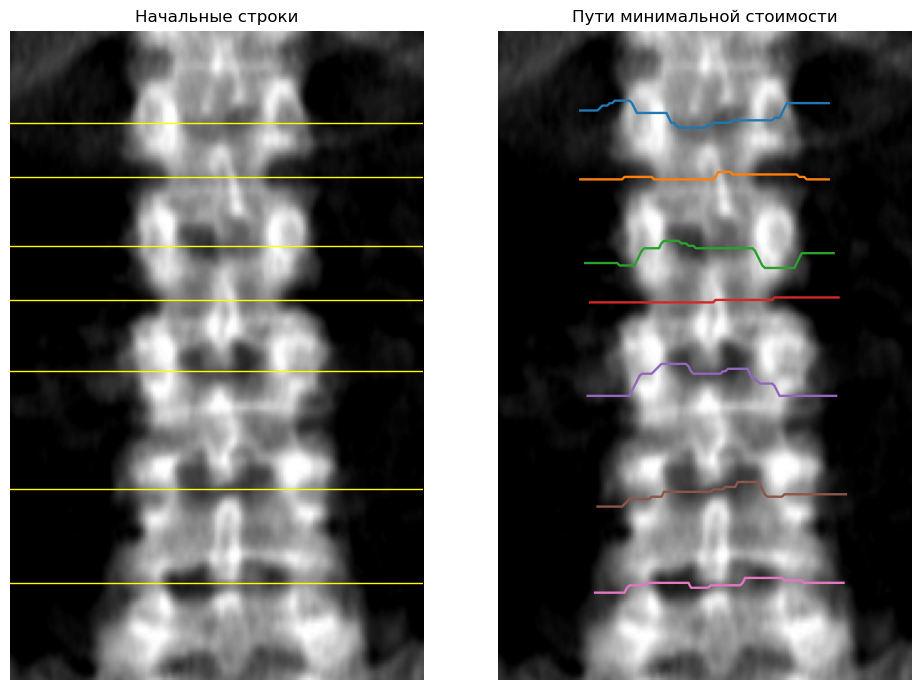

In [5]:
def path_for_gap(a,seed_y,center,half_width_fraction=.30,band_fraction=.038,slope_penalty=.060,anchor_penalty=.020):
    h,w=a.shape
    cx=int(round(center[seed_y]))
    xa,xb=max(0,int(cx-half_width_fraction*w)),min(w,int(cx+half_width_fraction*w)+1)
    band=max(9,int(h*band_fraction))
    ya,yb=max(0,int(seed_y-band)),min(h,int(seed_y+band+1))
    raw=gaussian_filter(a[ya:yb,xa:xb].astype(float),(.7,1.0))
    if raw.shape[0]<4 or raw.shape[1]<4: raise ValueError('Слишком узкая полоса для пути')
    normalized=(raw-np.quantile(raw,.05))/max(np.quantile(raw,.95)-np.quantile(raw,.05),1e-6)
    normalized=np.clip(normalized,0,1)
    rows=np.arange(ya,yb)
    cost=normalized + anchor_penalty*((rows[:,None]-seed_y)/max(band,1))**2
    H,W=cost.shape
    dp=np.empty((H,W),float);parent=np.zeros((H,W),np.int16)
    dp[:,0]=cost[:,0] + .12*((rows-seed_y)/max(band,1))**2
    for x in range(1,W):
        opts=np.full((5,H),np.inf)
        for k,step in enumerate(range(-2,3)):
            # current row r, previous row r-step
            if step>=0:opts[k,step:]=dp[:H-step,x-1]+slope_penalty*abs(step)
            else:opts[k,:step]=dp[-step:,x-1]+slope_penalty*abs(step)
        arg=np.argmin(opts,axis=0)
        dp[:,x]=cost[:,x]+opts[arg,np.arange(H)]
        parent[:,x]=arg-2
    row=int(np.argmin(dp[:,-1]+.12*((rows-seed_y)/max(band,1))**2))
    path=np.empty(W,dtype=np.int32)
    for x in range(W-1,-1,-1):
        path[x]=row+ya
        if x>0: row-=int(parent[row,x])
    return np.column_stack([np.arange(xa,xb),path])

paths=[path_for_gap(roi,int(g),center) for g in gaps]
fig,ax=plt.subplots(1,2,figsize=(10,7))
ax[0].imshow(roi,cmap='gray');ax[1].imshow(roi,cmap='gray')
for i,(g,p) in enumerate(zip(gaps,paths)):
    ax[0].axhline(g,color='yellow',lw=1)
    ax[1].plot(p[:,0],p[:,1],lw=1.7,label=f'G{i+1}')
ax[0].set_title('Начальные строки');ax[1].set_title('Пути минимальной стоимости')
for a in ax:a.axis('off')
plt.tight_layout();plt.show()

## 5. Оси условных сегментов и общая ось

По границам найденных промежутков разбиваем центральную линию на сегменты и в каждом оцениваем наклон оси `x(y)` линейной регрессией. Первый/последний сегменты могут быть неполными. Нумерация `S1...` означает порядок сверху вниз; она **не приписывает** автоматически уровень Th12 или L5. График сравнивает результаты трёх методов на полном изображении.

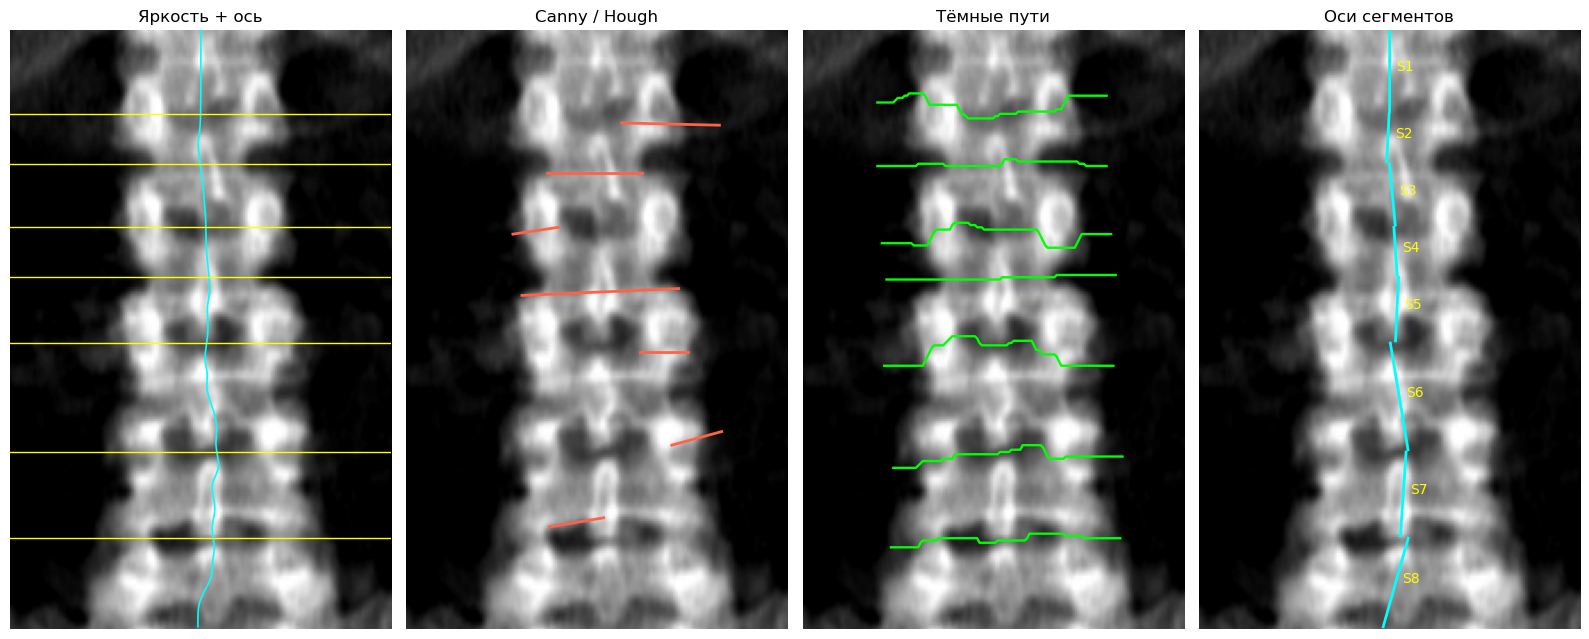

,name,y_top,y_bottom,slope_dx_dy,intercept,angle_from_vertical_deg,partial_view
0,S1,0,36,-0.001941,84.148668,-0.111191,True
1,S2,37,58,-0.048839,85.687872,-2.796053,False
2,S3,59,86,0.093587,78.524760,5.346574,False
3,S4,87,108,0.067011,80.166211,3.833727,False
4,S5,109,137,-0.046783,93.129447,-2.678500,False
5,S6,138,185,0.165697,61.556265,9.408240,False
6,S7,186,223,-0.067032,103.824829,-3.834906,False
7,S8,224,263,-0.282000,155.458355,-15.748463,True


In [6]:
def segments_from_gaps(center,gaps,min_rows=15):
    h=len(center)
    edges=np.r_[0,np.sort(gaps),h]
    segments=[]
    for i,(a,b) in enumerate(zip(edges[:-1],edges[1:]),1):
        a,b=int(a),int(b)
        if b-a<min_rows:continue
        trim=max(1,int((b-a)*.12))
        yy=np.arange(a+trim,b-trim)
        if len(yy)<3:continue
        slope,intercept=np.polyfit(yy,center[yy],1)
        segments.append({'name':f'S{i}','y_top':a,'y_bottom':b-1,
                         'slope_dx_dy':float(slope),'intercept':float(intercept),
                         'angle_from_vertical_deg':float(np.degrees(np.arctan(slope))),
                         'partial_view':i==1 or i==len(edges)-1})
    return segments

segments=segments_from_gaps(center,gaps)
fig,ax=plt.subplots(1,4,figsize=(16,8),sharex=True,sharey=True)
for a,title in zip(ax,['Яркость + ось','Canny / Hough','Тёмные пути','Оси сегментов']):
    a.imshow(image,cmap='gray',vmin=0,vmax=1)
    a.set_xlim(x0,x1);a.set_ylim(y1,y0);a.set_title(title);a.axis('off')
ax[0].plot(center+x0,np.arange(len(center))+y0,color='cyan',lw=1.2)
for g in gaps:ax[0].axhline(g+y0,color='yellow',lw=1)
for r in hough:
    if r['line'] is not None:
        p=r['line'];ax[1].plot([p[0]+x0,p[2]+x0],[p[1]+y0,p[3]+y0],color='tomato',lw=2)
for p in paths:ax[2].plot(p[:,0]+x0,p[:,1]+y0,color='lime',lw=1.7)
for s in segments:
    ys=np.array([s['y_top'],s['y_bottom']])
    xs=s['intercept']+s['slope_dx_dy']*ys
    ax[3].plot(xs+x0,ys+y0,color='cyan',lw=2)
    ax[3].text(xs.mean()+x0+3,ys.mean()+y0,s['name'],color='yellow',fontsize=10)
plt.tight_layout();plt.show()
display(pd.DataFrame(segments))
if not len(gaps):print('Ни одного кандидата: оси/линии не оцениваются. Проверьте ROI и яркость.')

## 6. MedSAM: установка, веса и прямоугольники (опционально)

Если появляется `ModuleNotFoundError: No module named 'segment_anything'`, установите пакет **в активное ядро ноутбука**, запустив отдельно новую ячейку:

```python
%pip install git+https://github.com/facebookresearch/segment-anything.git
```

После установки перезапустите ядро VS Code Jupyter и выполните ноутбук сверху вниз. `%pip` направляет установку в окружение текущего ядра; при установке из терминала проверяйте путь `sys.executable`, который показан ниже. Команда установки соответствует [официальному README Segment Anything](https://github.com/facebookresearch/segment-anything). Для данной функции требуются также `torch`, файл **MedSAM** `medsam_vit_b.pth` и непустой словарь `VERTEBRA_BOXES` в настройках. Обычный checkpoint SAM здесь не подходит. [README MedSAM](https://github.com/bowang-lab/MedSAM) описывает получение своих весов.

При `RUN_MEDSAM=False` установка не требуется. Прямоугольники задаются как `(x0, y0, x1, y1)` в координатах полного исходного кадра. Сегментация DXA экспериментальна.

In [7]:
import importlib.util, sys
print('Ядро Python:', sys.executable)
print('segment_anything установлен:', importlib.util.find_spec('segment_anything') is not None)
print('Веса MedSAM найдены:', MEDSAM_CHECKPOINT.is_file(), '|', MEDSAM_CHECKPOINT)
print('Боксов для MedSAM:', len(VERTEBRA_BOXES))
if RUN_MEDSAM and importlib.util.find_spec('segment_anything') is None:
    print('Установка в новую ячейку: %pip install git+https://github.com/facebookresearch/segment-anything.git')

Ядро Python: c:\ProgramData\anaconda3\envs\ml_env_py311\python.exe
segment_anything установлен: True
Веса MedSAM найдены: False | C:\Users\Андрей\Desktop\Хакатон\medsam_vit_b.pth
Боксов для MedSAM: 0


In [8]:
def geometry_from_mask(mask,name):
    ys,xs=np.where(mask)
    if len(xs)<40: return None
    x_left,x_right=np.quantile(xs,[.12,.88])
    bounds=[]
    for x in [x_left,x_right]:
        nearby=ys[np.abs(xs-x)<max(3,int((x_right-x_left)*.08))]
        if len(nearby)<8:return None
        bounds.append(np.quantile(nearby,[.08,.92]))
    (tl_y,bl_y),(tr_y,br_y)=bounds
    tl=np.array([x_left,tl_y]);tr=np.array([x_right,tr_y])
    bl=np.array([x_left,bl_y]);br=np.array([x_right,br_y])
    up=(tl+tr)/2;low=(bl+br)/2
    if low[1]<=up[1]:return None
    angle=float(np.degrees(np.arctan2(low[0]-up[0],low[1]-up[1])))
    return {'name':name,'tl':tl,'tr':tr,'bl':bl,'br':br,'upper_center':up,'lower_center':low,
            'angle_from_vertical_deg':angle}

def show_mask_geometry(img,masks,boxes,title):
    fig,ax=plt.subplots(figsize=(7,10));ax.imshow(img,cmap='gray')
    colors=plt.cm.tab10(np.linspace(0,1,max(len(masks),1)))
    rows=[]
    for (name,mask),color in zip(masks.items(),colors):
        if mask.shape!=img.shape:raise ValueError(f'Неверный размер маски {name}: {mask.shape}')
        ax.contour(mask.astype(float),levels=[.5],colors=[color],linewidths=1)
        if name in boxes:
            xa,ya,xb,yb=boxes[name]
            ax.add_patch(Rectangle((xa,ya),xb-xa,yb-ya,fill=False,edgecolor=color,lw=1,ls='--'))
        geom=geometry_from_mask(mask,name)
        if geom is None:
            rows.append({'name':name,'status':'геометрия не определена'});continue
        for x in ('tl','tr','bl','br'):
            ax.scatter(*geom[x],color=color,s=12)
        ax.plot([geom['tl'][0],geom['tr'][0]],[geom['tl'][1],geom['tr'][1]],color=color)
        ax.plot([geom['bl'][0],geom['br'][0]],[geom['bl'][1],geom['br'][1]],color=color)
        ax.plot([geom['upper_center'][0],geom['lower_center'][0]],
                [geom['upper_center'][1],geom['lower_center'][1]],color=color,ls=':',lw=2)
        rows.append({'name':name,'status':'ok','angle_deg':geom['angle_from_vertical_deg'],
                     'mask_pixels':int(mask.sum())})
    ax.set_title(title);ax.axis('off');plt.tight_layout();plt.show()
    return pd.DataFrame(rows)

def run_medsam(img,boxes,checkpoint):
    # Проверяем конфигурацию до импорта тяжёлой зависимости.
    if not Path(checkpoint).is_file():
        raise FileNotFoundError(
            f'Не найдены веса MedSAM: {checkpoint}. Укажите путь к medsam_vit_b.pth'
        )
    if not boxes:
        raise ValueError('Сначала заполните VERTEBRA_BOXES: {"L1": (x0,y0,x1,y1), ...}')
    try:
        import torch
        from segment_anything import sam_model_registry, SamPredictor
    except ModuleNotFoundError as exc:
        if exc.name == 'segment_anything':
            import sys
            raise ModuleNotFoundError(
                "Для MedSAM отсутствует пакет segment_anything в ядре Jupyter "
                f"({sys.executable}). Выполните в отдельной ячейке: "
                "%pip install git+https://github.com/facebookresearch/segment-anything.git "
                "Затем перезапустите ядро и запустите ноутбук снова."
            ) from exc
        raise
    device='cuda' if torch.cuda.is_available() else 'cpu'
    model=sam_model_registry['vit_b'](checkpoint=str(checkpoint)).to(device).eval()
    predictor=SamPredictor(model)
    rgb=np.repeat(np.uint8(np.clip(img,0,1)*255)[:,:,None],3,axis=2)
    predictor.set_image(rgb)
    h,w=img.shape;out={}
    with torch.inference_mode():
        for name,box in boxes.items():
            xa,ya,xb,yb=map(float,box)
            if not (0<=xa<xb<=w and 0<=ya<yb<=h):raise ValueError(f'Неверный box {name}: {box}')
            masks,scores,_=predictor.predict(box=np.array([xa,ya,xb,yb],dtype=np.float32),multimask_output=False)
            out[name]=masks[0].astype(bool)
    return out

if RUN_MEDSAM:
    medsam_masks=run_medsam(image,VERTEBRA_BOXES,MEDSAM_CHECKPOINT)
    display(show_mask_geometry(image,medsam_masks,VERTEBRA_BOXES,'MedSAM: маски и приближённые оси'))
else:
    print('MedSAM выключен; результат модели не подставляется искусственно.')

MedSAM выключен; результат модели не подставляется искусственно.


## 7. SAM 2 на тех же боксах (опционально)

Если вы хотите сравнить универсальную модель, установите `sam2` по [официальным инструкциям](https://github.com/facebookresearch/segment-anything-2), укажите совместимые конфигурацию и checkpoint и включите флаг. В версиях SAM 2 имена конфигураций менялись, поэтому проверьте соответствие вашей установленной версии. На Windows авторам предпочтительна среда WSL.

In [9]:
def run_sam2(img,boxes,checkpoint,config):
    import torch
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    if not Path(checkpoint).is_file():raise FileNotFoundError(checkpoint)
    if not boxes:raise ValueError('Сначала заполните VERTEBRA_BOXES')
    device='cuda' if torch.cuda.is_available() else 'cpu'
    predictor=SAM2ImagePredictor(build_sam2(config,str(checkpoint),device=device))
    rgb=np.repeat(np.uint8(np.clip(img,0,1)*255)[:,:,None],3,axis=2)
    h,w=img.shape;out={}
    with torch.inference_mode():
        predictor.set_image(rgb)
        for name,box in boxes.items():
            xa,ya,xb,yb=map(float,box)
            if not (0<=xa<xb<=w and 0<=ya<yb<=h):raise ValueError(f'Неверный box {name}: {box}')
            masks,scores,_=predictor.predict(box=np.array([xa,ya,xb,yb],np.float32),multimask_output=False)
            out[name]=np.asarray(masks[0],dtype=bool)
    return out

if RUN_SAM2:
    sam2_masks=run_sam2(image,VERTEBRA_BOXES,SAM2_CHECKPOINT,SAM2_CONFIG)
    display(show_mask_geometry(image,sam2_masks,VERTEBRA_BOXES,'SAM 2: маски и приближённые оси'))
else:
    print('SAM 2 выключен; результат модели не подставляется искусственно.')

SAM 2 выключен; результат модели не подставляется искусственно.


## 8. RouterNet: экспериментальный запуск готовых весов

В отличие от прежней версии, эта секция **пытается запустить сеть** при `RUN_ROUTERNET=True`. При `AUTO_CLONE_ROUTERNET=True` и установленном Git ноутбук сам клонирует [официальный RouterNet](https://github.com/YingJGuo/RouterNet) в `ROUTERNET_REPO` при первом запуске на настоящем снимке. Репозиторий включает два больших checkpoint и занимает несколько сотен мегабайт. Если Git отсутствует или загрузка прервалась, установите Git и повторите ячейку либо клонируйте репозиторий самостоятельно. Если папка уже существует, но в ней нет `utils.py`, ноутбук не будет её удалять и попросит исправить путь или неполную загрузку. В репозитории должен находиться `model/Jul25-1445_root_8/best_corner`. Используйте отдельное окружение с CUDA, PyTorch и зависимостями репозитория (`einops`, `albumentations`, `tensorboardX`). При первом вызове PreciseRoIPooling компилирует CUDA-расширение и требует установленного CUDA Toolkit и компилятора; нативный Windows может потребовать ручной настройки сборки. **CPU в официальном коде не поддерживается.**

Официальный `test.py` использует 704×384 и истинные углы **17** позвонков для инициализации; в вашем кадре около шести поясничных структур, поэтому даже успешный запуск сети не даёт подтверждённых уровней L1–L5. Здесь для запуска без экспертных точек используется *начальная форма из checkpoint*, масштабированная по ROI. До модели показывается начальная форма; после модели — все 17 предсказанных наборов углов. Это проверка переносимости на DXA, а не валидированное измерение. Для результата сохраняются только полностью попавшие в кадр четверки точек с метками `P01...P17` (индексы модели, не анатомические уровни).

Дополнительно можно импортировать CSV с координатами в исходном кадре: `image_id,level,tl_x,tl_y,tr_x,tr_y,bl_x,bl_y,br_x,br_y`. Порядок `tl,tr,bl,br` сверён с опубликованной экспертной разметкой. [Реализация теста RouterNet](https://github.com/YingJGuo/RouterNet/blob/main/test.py) и [PreciseRoIPooling](https://github.com/YingJGuo/RouterNet/blob/main/PreciseRoIPooling/pytorch/prroi_pool/functional.py).

In [10]:
def ensure_routernet_repo(repo,auto_clone=True):
    """Получить официальный код с готовыми весами один раз; не менять существующую папку."""
    import shutil, subprocess
    repo=Path(repo)
    if (repo/'utils.py').is_file():
        print('RouterNet найден:',repo)
        return True
    if repo.exists():
        print('Папка существует, но utils.py отсутствует:',repo)
        print('Проверьте ROUTERNET_REPO или завершите прерванное клонирование вручную.')
        return False
    if not auto_clone:
        print('RouterNet не найден:',repo)
        print('Клонируйте https://github.com/YingJGuo/RouterNet.git в ROUTERNET_REPO.')
        return False
    if shutil.which('git') is None:
        print('Команда git недоступна в системе. Установите Git для Windows или клонируйте RouterNet вручную.')
        print('Адрес: https://github.com/YingJGuo/RouterNet.git')
        return False
    repo.parent.mkdir(parents=True,exist_ok=True)
    print('Загружаю официальный RouterNet с checkpoint в:',repo,flush=True)
    try:
        subprocess.run(['git','clone','--depth','1',
                        'https://github.com/YingJGuo/RouterNet.git',str(repo)],
                       check=True,timeout=900)
    except (subprocess.CalledProcessError,subprocess.TimeoutExpired,OSError) as exc:
        print('Не удалось клонировать RouterNet:',exc)
        print('Проверьте доступ к GitHub. Если появилась неполная папка, исправьте её вручную.')
        return False
    success=(repo/'utils.py').is_file()
    print('Код RouterNet загружен.' if success else 'Файла utils.py после загрузки нет; проверьте репозиторий.')
    return success

def router_bbox_model(img_shape, region_box, manual_bbox=None):
    """Инициализация mean shape, bbox в сетке 384×704; без экспертных точек."""
    h,w=img_shape
    if manual_bbox is not None:
        box=np.asarray(manual_bbox,dtype=np.float32)
    else:
        xa,ya,xb,yb=region_box
        cx=(xa+xb)/2*384/w;cy=(ya+yb)/2*704/h
        span=(yb-ya)*704/h
        box=np.array([cx-span/8,cy-span/4,cx+span/8,cy+span/4],dtype=np.float32)
    if box.shape!=(4,) or not np.all(np.isfinite(box)) or box[2]<=box[0] or box[3]<=box[1]:
        raise ValueError('ROUTERNET_BBOX_704: ожидаются x0,y0,x1,y1, x1>x0 и y1>y0')
    return box

def run_routernet(img,region_box,repo,checkpoint,manual_bbox=None):
    """Реальный forward RouterNet: mean shape -> 17 центров и 68 углов."""
    import importlib.util, sys
    repo=Path(repo).resolve();checkpoint=Path(checkpoint).resolve()
    if not (repo/'utils.py').is_file():raise FileNotFoundError(f'Не найден RouterNet/utils.py: {repo}')
    if not checkpoint.is_file():raise FileNotFoundError(f'Не найден checkpoint best_corner: {checkpoint}')
    missing=[k for k in ('torch','tensorboardX','einops','albumentations')
             if importlib.util.find_spec(k) is None]
    if missing:raise ModuleNotFoundError('В активном ядре нет зависимостей RouterNet: '+', '.join(missing))
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('RouterNet/PreciseRoIPooling требует CUDA; в этом ядре torch.cuda.is_available()=False')
    input_img=cv2.resize(np.uint8(np.clip(img,0,1)*255),(384,704),interpolation=cv2.INTER_AREA)
    bbox=router_bbox_model(img.shape,region_box,manual_bbox)
    # utils.py разбирает sys.argv при импорте; временно скрываем аргументы Jupyter.
    old_argv=sys.argv[:]
    added=str(repo) not in sys.path
    if added:sys.path.insert(0,str(repo))
    try:
        sys.argv=[str(repo/'utils.py')]
        spec=importlib.util.spec_from_file_location('_routernet_official_utils',repo/'utils.py')
        module=importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        state,mean_rcenter,mean_rcorner=module.LoadModels(str(checkpoint))
        mean_rcenter=np.asarray(mean_rcenter,dtype=np.float32)
        mean_rcorner=np.asarray(mean_rcorner,dtype=np.float32)
        if mean_rcenter.shape!=(17,2) or mean_rcorner.shape!=(68,2):
            raise ValueError(f'Неожиданная форма mean shape: {mean_rcenter.shape}, {mean_rcorner.shape}')
        initial_centers=module.Shape2Absolute(mean_rcenter,bbox).astype(np.float32)
        initial_corners=module.Shape2Absolute(mean_rcorner,bbox).astype(np.float32)
        corner_offsets,_=module.GenerateCornerVec(initial_corners)
        heads={'corner':8,'center':34,'center_pt':2}
        # pretrained=False предотвращает лишнюю загрузку ImageNet: все веса приходят из checkpoint.
        net=module.SpineNet(heads=heads,center_num=17,
                            recurrent_num=module.args.param_recurrent_num,
                            local_win=module.args.param_local_win,pretrained=False)
        net.load_state_dict(state,strict=True)
        net.cuda().eval()
        x=torch.from_numpy(input_img.astype(np.float32)).cuda()[None,None]/255.
        x=x.repeat(1,3,1,1)
        c=torch.from_numpy(initial_centers).cuda()[None]
        offsets=torch.from_numpy(corner_offsets).cuda()[None]
        with torch.inference_mode():
            prediction=net(x,1,c,offsets,module.args.root_idx)
        centers=prediction['center_pts_pos_2'][0].detach().cpu().numpy().reshape(17,2)
        corners=prediction['corner_pts_pos_2'][0].detach().cpu().numpy().reshape(17,4,2)
    finally:
        sys.argv=old_argv
        if added:sys.path.remove(str(repo))
    scale=np.array([img.shape[1]/384.,img.shape[0]/704.],dtype=np.float32)
    return {'input_img':input_img,'bbox':bbox,
            'initial_centers_model':initial_centers,'initial_corners_model':initial_corners.reshape(17,4,2),
            'centers_model':centers,'corners_model':corners,
            'centers_original':centers*scale,'corners_original':corners*scale}

def show_router_result(original,result):
    fig,axes=plt.subplots(1,3,figsize=(15,8))
    init=result['initial_corners_model'];pred=result['corners_model']
    for a,title,pts in zip(axes[:2],['Инициализация из checkpoint','RouterNet: 17 предсказаний'],[init,pred]):
        a.imshow(result['input_img'],cmap='gray')
        for i,q in enumerate(pts):
            a.scatter(q[:,0],q[:,1],s=5,color='cyan' if i<11 else 'yellow')
            a.text(np.mean(q[:,0]),np.mean(q[:,1]),str(i+1),color='red',fontsize=7)
        a.set_xlim(0,384);a.set_ylim(704,0);a.set_title(title);a.axis('off')
    a=axes[2];a.imshow(original,cmap='gray')
    for i,q in enumerate(result['corners_original']):
        a.scatter(q[:,0],q[:,1],s=6,color='yellow')
        a.text(np.mean(q[:,0]),np.mean(q[:,1]),str(i+1),color='red',fontsize=7)
    a.set_xlim(0,original.shape[1]);a.set_ylim(original.shape[0],0)
    a.set_title('Точки в координатах DXA');a.axis('off')
    plt.tight_layout();plt.show()

def prediction_to_csv(result,image_id,path):
    h,w=result['input_img'].shape
    rows=[];skipped=[]
    for i,q in enumerate(result['corners_model']):
        if not np.isfinite(q).all() or not ((q[:,0]>=0)&(q[:,0]<w)&(q[:,1]>=0)&(q[:,1]<h)).all():
            skipped.append(i+1);continue
        mapped=result['corners_original'][i]
        rows.append({'image_id':image_id,'level':f'P{i+1:02d}',
                     **{f'{label}_{axis}':float(mapped[j,k])
                        for j,label in enumerate(('tl','tr','bl','br'))
                        for k,axis in enumerate(('x','y'))}})
    table=pd.DataFrame(rows,columns=LANDMARK_COLUMNS)
    if len(table):
        path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
        table.to_csv(path,index=False)
    return table,skipped

LANDMARK_COLUMNS=['image_id','level','tl_x','tl_y','tr_x','tr_y',
                  'bl_x','bl_y','br_x','br_y']

def load_landmark_csv(path,image_id,img):
    if not Path(path).is_file():return pd.DataFrame(columns=LANDMARK_COLUMNS)
    df=pd.read_csv(path,dtype={'image_id':str,'level':str})
    missing=set(LANDMARK_COLUMNS)-set(df.columns)
    if missing:raise ValueError(f'В файле ориентиров отсутствуют поля: {sorted(missing)}')
    df=df.loc[df.image_id.astype(str).eq(image_id),LANDMARK_COLUMNS].copy()
    if df.level.duplicated().any():raise ValueError('Дублируются уровни в CSV; уточните image_id и level')
    h,w=img.shape
    for c in LANDMARK_COLUMNS[2:]:df[c]=pd.to_numeric(df[c],errors='raise')
    for part in ['tl','tr','bl','br']:
        if not (df[f'{part}_x'].ge(0)&df[f'{part}_x'].lt(w)&df[f'{part}_y'].ge(0)&df[f'{part}_y'].lt(h)).all():
            raise ValueError(f'Точки {part} лежат за пределами кадра; проверьте масштабирование')
    return df

def show_landmarks(img,df):
    fig,ax=plt.subplots(figsize=(7,10));ax.imshow(img,cmap='gray')
    table=[]
    for _,r in df.iterrows():
        pts={k:np.array([r[f'{k}_x'],r[f'{k}_y']],dtype=float) for k in ['tl','tr','bl','br']}
        if not (pts['tl'][1]<pts['bl'][1] and pts['tr'][1]<pts['br'][1]):
            warnings.warn(f"Проверьте порядок четырёх точек: {r['level']}")
        upper=(pts['tl']+pts['tr'])/2;lower=(pts['bl']+pts['br'])/2
        angle=float(np.degrees(np.arctan2(lower[0]-upper[0],lower[1]-upper[1])))
        for a,b,style in [('tl','tr','-'),('bl','br','-'),('tl','bl',':'),('tr','br',':')]:
            ax.plot([pts[a][0],pts[b][0]],[pts[a][1],pts[b][1]],style,color='lime')
        ax.plot([upper[0],lower[0]],[upper[1],lower[1]],color='cyan',lw=2)
        ax.text(upper[0],upper[1]-3,str(r['level']),color='yellow')
        table.append({'level':r['level'],'angle_from_vertical_deg':angle})
    ax.set_title('RouterNet: импорт ориентиров в исходном кадре');ax.axis('off')
    plt.tight_layout();plt.show()
    return pd.DataFrame(table)

# Автоматический запуск только на реальном снимке и при наличии репозитория.
if is_synthetic:
    print('RouterNet не запускается на синтетическом снимке.')
elif RUN_ROUTERNET:
    if ensure_routernet_repo(ROUTERNET_REPO,AUTO_CLONE_ROUTERNET):
        if not ROUTERNET_CHECKPOINT.is_file():
            print('Нет весов RouterNet best_corner:',ROUTERNET_CHECKPOINT)
        else:
            result=run_routernet(image,(x0,y0,x1,y1),ROUTERNET_REPO,
                                 ROUTERNET_CHECKPOINT,ROUTERNET_BBOX_704)
            show_router_result(image,result)
            predicted,skipped=prediction_to_csv(result,image_id,ROUTERNET_CSV)
            print('Четверки точек внутри кадра:',len(predicted),'/17; вне кадра:',skipped)
            if len(predicted):
                print('Результат модели:',ROUTERNET_CSV)
                display(show_landmarks(image,predicted))
else:
    print('RouterNet выключен; измените RUN_ROUTERNET=True в настройках.')

# Допускается также просмотр заранее экспортированных предсказаний для этого изображения.
if not (RUN_ROUTERNET and not is_synthetic and ROUTERNET_REPO.is_dir() and ROUTERNET_CHECKPOINT.is_file()):
    imported=load_landmark_csv(ROUTERNET_CSV,image_id,image)
    if len(imported):display(show_landmarks(image,imported))
    else:print('Нет CSV с ориентирами для этого снимка.')


RouterNet найден: C:\Users\Андрей\Desktop\Хакатон\RouterNet


ModuleNotFoundError: В активном ядре нет зависимостей RouterNet: tensorboardX, einops, albumentations

## 9. Сопоставление и сохранение базовых координат

Таблицы сохраняются только при работе с реальным DICOM. Названия `G1…` и `S1…` обозначают порядок, а не подтверждённые анатомические уровни. Для сравнения с экспертной разметкой отметьте тот же набор межпозвонковых уровней и четыре угла; оценивайте ошибку отдельно по снимкам, не рассматривайте найденные линии как клиническое заключение.

In [ ]:
gap_table=pd.DataFrame([{'image_id':image_id,'gap_order':i+1,'seed_y_px':int(y0+g),
    'prominence':float(strengths[i]),
    'hough_found':hough[i]['line'] is not None,
    'hough_mid_y_px':float(y0+(hough[i]['line'][1]+hough[i]['line'][3])/2) if hough[i]['line'] is not None else np.nan,
    'path_mid_y_px':float(y0+np.median(paths[i][:,1]))}
    for i,g in enumerate(gaps)])
segment_table=pd.DataFrame(segments)
if not segment_table.empty:
    segment_table.insert(0,'image_id',image_id)
    segment_table['y_top_px']=segment_table.y_top+y0
    segment_table['y_bottom_px']=segment_table.y_bottom+y0
print('Найдены кандидаты; здесь нет оценки точности без экспертной разметки.')
display(gap_table)
if not is_synthetic:
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    gap_table.to_csv(OUTPUT_DIR/(image_id+'_gaps.csv'),index=False)
    segment_table.to_csv(OUTPUT_DIR/(image_id+'_axes.csv'),index=False)
    print('Сохранены координаты для ручной проверки в',OUTPUT_DIR)

### Где адаптировать для вашего набора

- Проверьте инверсию яркости и выставьте ROI по реальному снимку; в прямой проекции «тёмный промежуток» может быть неоднозначным из-за наложений.
- Сопоставьте `G1...` с уровнями вручную; затем используйте 15–20 экспертно размеченных снимков, включая Th12 и L4–L5.
- Hough и DP измеряют **разные геометрические объекты** (краевой сегмент и путь через тёмную полосу); сравнивайте каждый с соответствующим экспертным ориентиром.
- Маски MedSAM/SAM 2 требуют заданных боксов. Оценка углов из крайних пикселей маски — лишь приближение; сопоставьте их с экспертными четырьмя точками.
- Без DICOM и весов мы можем проверить исполнение классических функций на синтетике, но не заявлять качество на DXA.